<font color=white size=8 face=雅黑>**用于DOS分析-实例化对象并获取相关信息**</font>

In [1]:
from pathlib import Path
from pymatgen.electronic_structure.core import Spin
from VaspAnalysis import VaspDosAnalysis, DosPlt

# 1) 初始化 + 基本信息检查（DOSCAR + POSCAR）
work_dir = Path("/data2/home/luodh/999/dos")      # 这里放 DOSCAR / POSCAR
out_dir  = Path("/data2/home/luodh/999/dos/result")  # 输出目录
out_dir.mkdir(parents=True, exist_ok=True)

dos = VaspDosAnalysis(
    work_dir=work_dir,
    save_data=True,
    output_dir=out_dir,
    doscar_file="DOSCAR",
    poscar_file="POSCAR",
)

print("DOSCAR:", dos.doscar_path)
print("POSCAR:", dos.poscar_path)
print("natoms:", dos.natoms)
print("ISPIN:", dos.ispin)
print("NEDOS:", dos.ndata)
print("Efermi (from DOSCAR):", dos.dos_efermi)
print("n_orbitals:", dos.n_orbitals)
print("available orbital keys (first 30):", sorted(list(dos.orbital_map.keys()))[:30])


[Info] Detected LORBIT>=11 mode (s + p3 + d5 components).
[Info] PDOS loaded. Shape=(80, 3001, 9, 2), ISPIN=2, NEDOS=3001


DOSCAR: /data2/home/luodh/999/dos/DOSCAR
POSCAR: /data2/home/luodh/999/dos/POSCAR
natoms: 80
ISPIN: 2
NEDOS: 3001
Efermi (from DOSCAR): 3.84783394
n_orbitals: 9
available orbital keys (first 30): ['all', 'd', 'dx2y2', 'dxy', 'dxz', 'dyz', 'dz2', 'p', 'px', 'py', 'pz', 's']


<font color=white size=8 face=雅黑>**DOS导出**</font>

In [ ]:
# 2) 导出 Total DOS（TDOS）
df_tdos = dos.parse_total_dos(
    save=True,
    filename="total_dos.csv"
)
print("TDOS df shape:", df_tdos.shape)
print(df_tdos.head())


# 3) 导出元素聚合 DOS
# 3.1 输出所有元素的 s/p/d（若存在 f 也可加进去）
df_el_spd = dos.parse_element_spd_dos(
    elements=None,                 # None => 所有元素
    orbitals=["s", "p", "d"],       # 你也可以换成 None => 输出所有可用 spd(/f)
    save=True,
    filename="element_spd_dos.csv"
)
print("Element SPD df shape:", df_el_spd.shape)

# 3.2 输出指定元素的 total PDOS（all）
df_el = dos.parse_element_dos(
    element=["Pd"],           # 按你的体系改
    save=True,
    filename="Pd_total_pdos.csv"
)
print("Elements total PDOS df shape:", df_el.shape)


# 4) 位点 DOS 导出（0-based site_index）
site_index = 0

# 4.1 位点总 PDOS（all）
df_site = dos.parse_site_dos(
    site_index=site_index,
    save=True,
    filename=None,                 # None => 自动命名
)
print("Site DOS df shape:", df_site.shape)

# 4.2 位点 SPD（s/p/d 或 s/p/d/f）
df_site_spd = dos.parse_site_spd_dos(
    site_index=site_index,
    orbitals=["s", "p", "d"],
    save=True,
    filename=None,
)
print("Site SPD df shape:", df_site_spd.shape)

# 4.3 位点子轨道分量（仅 LORBIT>=11 / 9或16分量模式可用）
#     例如：dxy/dyz/dz2/dxz/dx2y2、px/py/pz
df_site_sub = dos.parse_site_orbital_dos(
    site_index=site_index,
    orbitals=["dxy", "dyz", "dz2", "dxz", "dx2y2"],
    save=True,
    filename=None,
)
print("Site sub-orbital df shape:", df_site_sub.shape)

# 4.4 位点 t2g/eg（需要 d 分量存在）
df_t2g_eg = dos.parse_site_t2g_eg_dos(
    site_index=site_index,
    save=True,
    filename=None,
)
print("Site t2g/eg df shape:", df_t2g_eg.shape)

[Saved] total_dos.csv
[Info] Total DOS saved to total_dos.csv
[Info] Found 80 atoms of type 'Pd'.
[Info] Found 80 atoms of type 'Pd'.
[Info] Found 80 atoms of type 'Pd'.
[Saved] element_spd_dos.csv
[Info] Element SPD DOS saved to element_spd_dos.csv
[Info] Found 80 atoms of type 'Pd'.


TDOS df shape: (3001, 4)
   Energy(eV)  TDOS_up    efermi  TDOS_down
0   -7.452834      0.0  3.847834        0.0
1   -7.447834      0.0  3.847834        0.0
2   -7.442834      0.0  3.847834        0.0
3   -7.437834      0.0  3.847834        0.0
4   -7.432834      0.0  3.847834        0.0
Element SPD df shape: (3001, 8)


[Saved] Fe_O_total_pdos.csv
[Info] Elements total PDOS saved to Fe_O_total_pdos.csv
[Saved] site_0_Pd_dos.csv
[Info] Site 0 DOS saved to site_0_Pd_dos.csv
[Saved] site_0_Pd_s_p_d_dos.csv
[Info] Site 0 SPD DOS saved to site_0_Pd_s_p_d_dos.csv
[Saved] site_0_Pd_dxy_dyz_dz2_dxz_dx2y2_dos.csv
[Info] Site 0 sub-orbital DOS saved to site_0_Pd_dxy_dyz_dz2_dxz_dx2y2_dos.csv
[Saved] site_0_Pd_t2g_eg_dos.csv
[Info] Site 0 t2g/eg DOS saved to site_0_Pd_t2g_eg_dos.csv


Elements total PDOS df shape: (3001, 4)
Site DOS df shape: (3001, 4)
Site SPD df shape: (3001, 8)
Site sub-orbital df shape: (3001, 12)
Site t2g/eg df shape: (3001, 6)


<font color=white size=8 face=雅黑>**DOS绘图-保存为PDF/PNG**</font>

In [6]:
# 5) 绘图：用 DosPlt 叠加多个 DataFrame（PNG/PDF 都行）
pltter = DosPlt(
    zero_at_efermi=True,
    mirror_down=True,    # down 自旋镜像到负轴（传统 DOS 画法）
    line_width=1.5,
)

# 叠加：TDOS + 元素 SPD + 一个位点 t2g/eg
pltter.add_dos_df("TDOS", df_tdos)
if not df_el_spd.empty:
    pltter.add_dos_df("ElementSPD", df_el_spd)
if isinstance(df_t2g_eg, type(df_tdos)) and not df_t2g_eg.empty:
    pltter.add_dos_df("Site_t2g_eg", df_t2g_eg)

# 保存为 PNG（PPT 友好）
pltter.save_plot(
    out_dir / "dos_overlay.png",
    dpi=600,
    xlim=(-8, 6),
    beta_dashed=True
)

# 保存为 PDF（文章矢量图）
pltter.save_plot(
    out_dir / "dos_overlay.pdf",
    xlim=(-8, 6),
    beta_dashed=True
)

print("Plots saved to:", out_dir)


# 6) 统计量示例：d-band center / width / filling
# 6.1 全体系 d band center（spin=None => 若 ISPIN=2 则 up+down 总和）
dc_all = dos.get_band_center(band="d", spin=None, erange=(-8, 3))
dw_all = dos.get_band_width(band="d", spin=None, erange=(-8, 3))
fill_all = dos.get_band_filling(band="d", spin=None)

print("Global d-band center (sum spins if ISPIN=2):", dc_all)
print("Global d-band width  (sum spins if ISPIN=2):", dw_all)
print("Global d-band filling (Ef=0 occupied fraction):", fill_all)

# 6.2 指定元素（例如 Pd）的 d band center（按元素所有原子聚合）
dc_fe = dos.get_band_center(band="d", elements="Pd", spin=None, erange=(-8, 3))
print("Pd d-band center:", dc_fe)

# 6.3 指定位点（例如 0 和 1）的 d band center
dc_sites = dos.get_band_center(band="d", site_indices=[0, 1], spin=None, erange=(-8, 3))
print("Sites [0,1] d-band center:", dc_sites)

# 6.4 指定自旋通道（仅 ISPIN=2 可用）
if dos.ispin == 2:
    dc_up = dos.get_band_center(band="d", elements="Pd", spin=Spin.up, erange=(-8, 3))
    dc_dn = dos.get_band_center(band="d", elements="Pd", spin=Spin.down, erange=(-8, 3))
    print("Pd d-band center (up):", dc_up)
    print("Pd d-band center (down):", dc_dn)


# 7) 批处理示例：批量导出多个位点的 SPD + 快速画图
#    适合做高通量检查某几个关键位点
sites_to_scan = list(range(min(5, dos.natoms)))  # 前 5 个位点举例
for i in sites_to_scan:
    df_i = dos.parse_site_spd_dos(
        site_index=i,
        orbitals=["s", "p", "d"],
        save=True,
        filename=out_dir / f"site_{i}_spd_dos.csv",
    )

    p = DosPlt(zero_at_efermi=True, mirror_down=True, line_width=1.2)
    p.add_dos_df(f"site{i}", df_i)
    p.save_plot(
        out_dir / f"site_{i}_spd_dos.png",
        dpi=450,
        xlim=(-8, 6),
        beta_dashed=True,
    )

print("All done. Outputs saved to:", out_dir)

[Info] Found 80 atoms of type 'Pd'.
[Info] Found 80 atoms of type 'Pd'.
[Info] Found 80 atoms of type 'Pd'.
[Saved] /data2/home/luodh/999/dos/result/site_0_spd_dos.csv


Plots saved to: /data2/home/luodh/999/dos/result
Global d-band center (sum spins if ISPIN=2): -1.7145269042273128
Global d-band width  (sum spins if ISPIN=2): 1.394469670684173
Global d-band filling (Ef=0 occupied fraction): 0.9043755078646536
Pd d-band center: -1.7145269042273128
Sites [0,1] d-band center: -1.6880924427336468
Pd d-band center (up): -1.7130731866614737
Pd d-band center (down): -1.7159756644883222


[Info] Site 0 SPD DOS saved to /data2/home/luodh/999/dos/result/site_0_spd_dos.csv
[Saved] /data2/home/luodh/999/dos/result/site_1_spd_dos.csv
[Info] Site 1 SPD DOS saved to /data2/home/luodh/999/dos/result/site_1_spd_dos.csv
[Saved] /data2/home/luodh/999/dos/result/site_2_spd_dos.csv
[Info] Site 2 SPD DOS saved to /data2/home/luodh/999/dos/result/site_2_spd_dos.csv
[Saved] /data2/home/luodh/999/dos/result/site_3_spd_dos.csv
[Info] Site 3 SPD DOS saved to /data2/home/luodh/999/dos/result/site_3_spd_dos.csv
[Saved] /data2/home/luodh/999/dos/result/site_4_spd_dos.csv
[Info] Site 4 SPD DOS saved to /data2/home/luodh/999/dos/result/site_4_spd_dos.csv


All done. Outputs saved to: /data2/home/luodh/999/dos/result


<font color=white size=8 face=雅黑>**DOS绘图-分轨道信息**</font>

In [7]:
site_index = 0

# 1) 解析位点分轨道（子轨道）DOS -> DataFrame
df_site_d = dos.parse_site_orbital_dos(
    site_index=site_index,
    orbitals=["dxy", "dyz", "dz2", "dxz", "dx2y2"],  # d 五分量
    save=True,
    filename=out_dir / f"site_{site_index}_d_components.csv",
)
# 2) 绘图
p = DosPlt(zero_at_efermi=True, mirror_down=True, line_width=1.3)
p.add_dos_df(f"site{site_index}_d", df_site_d)

p.save_plot(
    out_dir / f"site_{site_index}_d_components.png",
    dpi=600,
    xlim=(-8, 6),
    beta_dashed=True,
)

##更多轨道信息
df_site_pd = dos.parse_site_orbital_dos(
    site_index=site_index,
    orbitals=["px", "py", "pz", "dxy", "dyz", "dz2", "dxz", "dx2y2"],
    save=True,
    filename=out_dir / f"site_{site_index}_p_d_components.csv",
)

p = DosPlt(zero_at_efermi=True, mirror_down=True, line_width=1.2)
p.add_dos_df(f"site{site_index}_p+d", df_site_pd)

p.save_plot(
    out_dir / f"site_{site_index}_p_d_components.pdf",  # 矢量图
    xlim=(-10, 5),
    beta_dashed=True,
)

##所有的轨道信息
df_site_all = dos.parse_site_orbital_dos(
    site_index=site_index,
    orbitals=None,  # 输出所有可用单分量
    save=True,
    filename=out_dir / f"site_{site_index}_all_suborbitals.csv",
)

p = DosPlt(zero_at_efermi=True, mirror_down=True, line_width=1.0)
p.add_dos_df(f"site{site_index}_all", df_site_all)

p.save_plot(
    out_dir / f"site_{site_index}_all_suborbitals.png",
    dpi=450,
    xlim=(-8, 6),
    beta_dashed=True,
)

[Saved] /data2/home/luodh/999/dos/result/site_0_d_components.csv
[Info] Site 0 sub-orbital DOS saved to /data2/home/luodh/999/dos/result/site_0_d_components.csv
[Saved] /data2/home/luodh/999/dos/result/site_0_p_d_components.csv
[Info] Site 0 sub-orbital DOS saved to /data2/home/luodh/999/dos/result/site_0_p_d_components.csv
[Saved] /data2/home/luodh/999/dos/result/site_0_all_suborbitals.csv
[Info] Site 0 sub-orbital DOS saved to /data2/home/luodh/999/dos/result/site_0_all_suborbitals.csv


In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, JSON

# 插入你的模块路径
sys.path.insert(0, "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/")

# 导入你写的类
from vasp_analysis_mod.Analysis import RelaxAnalysis, DosAnalysis, DoscarParser, CohpAnalysis

# 定义测试文件夹路径
RELAX_DIR   = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Relax-Test")
DOS_DIR     = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Doscar-Text")
LOBSTER_DIR = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Lobster-Text")

# 设置画图全局样式
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/outputs.py:3987: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as fid:


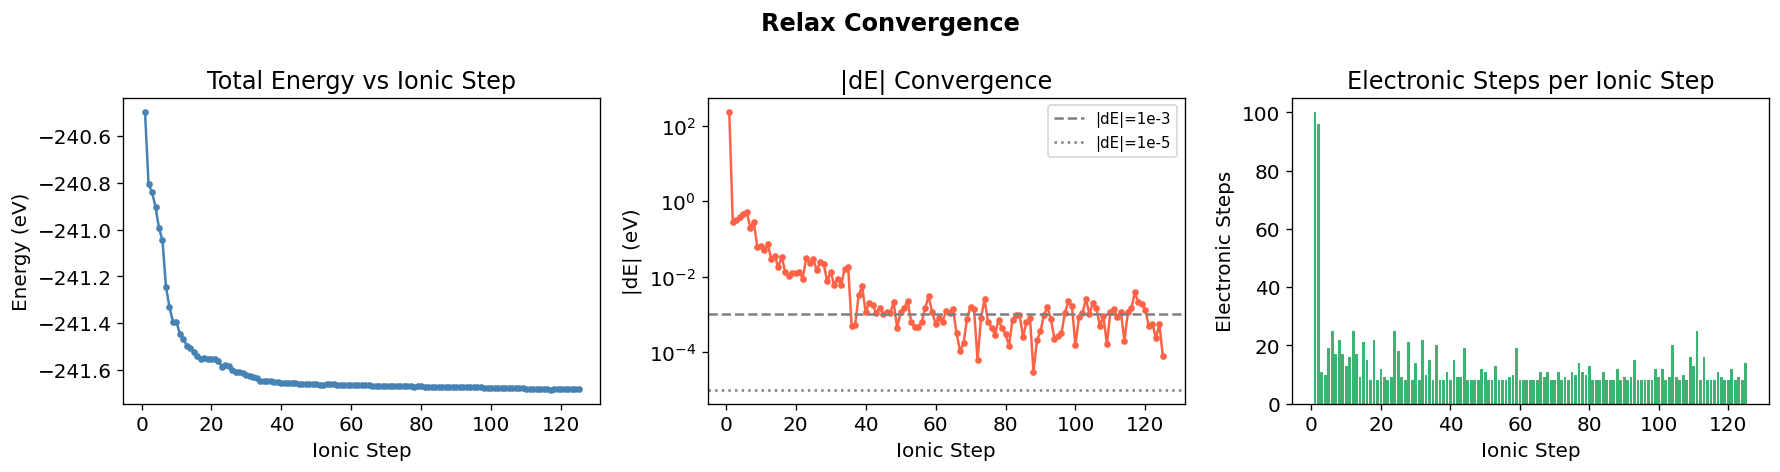

  总离子步: 125  |  平均电子步: 12.7


In [3]:
from pymatgen.io.vasp import Oszicar

osz = Oszicar(str(RELAX_DIR / "OSZICAR"))
ionic_steps = osz.ionic_steps

energies = [step.get("E0", np.nan) for step in ionic_steps]
dE_list  = [step.get("dE", np.nan) for step in ionic_steps]
elec_steps = [len(s) for s in osz.electronic_steps]
steps_idx  = list(range(1, len(ionic_steps) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Relax Convergence", fontweight="bold")

# 子图1: 能量收敛
axes[0].plot(steps_idx, energies, color="steelblue", marker=".")
axes[0].set_xlabel("Ionic Step")
axes[0].set_ylabel("Energy (eV)")
axes[0].set_title("Total Energy vs Ionic Step")

# 子图2: dE 收敛
dE_abs = [abs(x) for x in dE_list if x is not None]
axes[1].semilogy(steps_idx[:len(dE_abs)], dE_abs, color="tomato", marker=".")
axes[1].axhline(1e-3, color="gray", linestyle="--", label="|dE|=1e-3")
axes[1].axhline(1e-5, color="gray", linestyle=":",  label="|dE|=1e-5")
axes[1].set_xlabel("Ionic Step")
axes[1].set_ylabel("|dE| (eV)")
axes[1].set_title("|dE| Convergence")
axes[1].legend(fontsize=9)

# 子图3: 每离子步的电子步数
axes[2].bar(steps_idx, elec_steps, color="mediumseagreen", width=0.8)
axes[2].set_xlabel("Ionic Step")
axes[2].set_ylabel("Electronic Steps")
axes[2].set_title("Electronic Steps per Ionic Step")

plt.tight_layout()
plt.show()
print(f"  总离子步: {len(ionic_steps)}  |  平均电子步: {np.mean(elec_steps):.1f}")

位点磁矩（前 10 行）：


,atom_index,s,p,d,tot
0,0,0.004,-0.005,2.051,2.050
1,1,0.004,-0.004,2.053,2.052
2,2,0.004,-0.004,2.071,2.071
3,3,0.004,-0.004,2.064,2.064
4,4,0.009,-0.009,2.076,2.075
5,5,0.009,-0.010,2.073,2.073
6,6,0.009,-0.010,2.081,2.080
7,7,0.009,-0.010,2.081,2.081
8,8,-0.003,0.012,-2.017,-2.008
9,9,-0.003,0.011,-2.036,-2.029


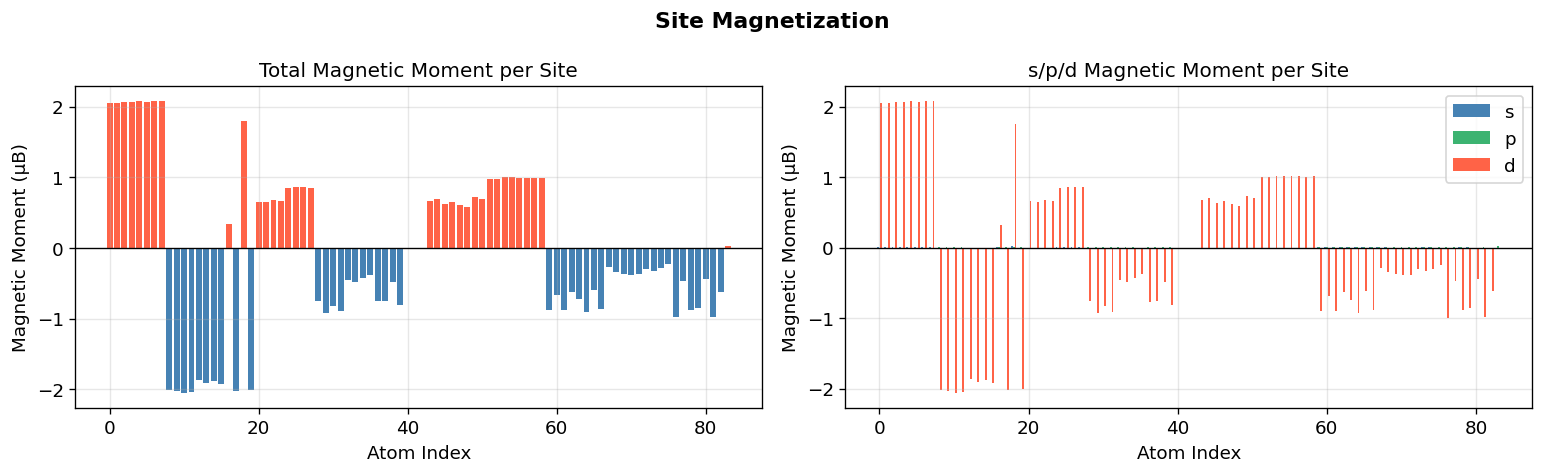

In [5]:
site_mag = d["site_magnetization"]

if site_mag:
    df_mag = pd.DataFrame(site_mag)
    print("位点磁矩（前 10 行）：")
    display(df_mag.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Site Magnetization", fontweight="bold")

    # 总磁矩分布
    axes[0].bar(df_mag["atom_index"], df_mag["tot"],
                color=["tomato" if v > 0 else "steelblue" for v in df_mag["tot"]])
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel("Atom Index")
    axes[0].set_ylabel("Magnetic Moment (μB)")
    axes[0].set_title("Total Magnetic Moment per Site")

    # spd 分解
    width = 0.25
    x = df_mag["atom_index"].values
    axes[1].bar(x - width, df_mag["s"],   width=width, label="s",  color="steelblue")
    axes[1].bar(x,         df_mag["p"],   width=width, label="p",  color="mediumseagreen")
    axes[1].bar(x + width, df_mag["d"],   width=width, label="d",  color="tomato")
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Atom Index")
    axes[1].set_ylabel("Magnetic Moment (μB)")
    axes[1].set_title("s/p/d Magnetic Moment per Site")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  无位点磁矩数据（非磁性体系）")

In [2]:
print("=== 1. 测试 RelaxAnalysis ===")
relax_analyzer = RelaxAnalysis(RELAX_DIR)

# 调用 analyze() 获取 ApiResponse 对象
relax_response = relax_analyzer.analyze()

print(f"解析是否成功: {relax_response.success}")
print(f"提示信息: {relax_response.message}")

if relax_response.success:
    relax_data = relax_response.data
    print(f"\n最终能量: {relax_data.get('final_energy_eV')} eV")
    print(f"费米能级: {relax_data.get('fermi_level_eV')} eV")
    print(f"离子步数: {relax_data.get('ionic_steps')}")
    
    # 验证 JSON 序列化 (测试 VaspJsonEncoder 是否生效)
    json_str = relax_response.to_json(indent=2)
    print("\n--- JSON 输出片段 (前500字符) ---")
    print(json_str[:500] + "\n... [截断]")

=== 1. 测试 RelaxAnalysis ===


/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/outputs.py:3987: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as fid:
/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/outputs.py:2047: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/outputs.py:2294: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(self.filename, mode="rt") as file:


解析是否成功: True
提示信息: Relax analysis complete: converged

最终能量: -241.68384 eV
费米能级: 0.3104 eV
离子步数: 125

--- JSON 输出片段 (前500字符) ---
{
  "success": true,
  "code": 200,
  "message": "Relax analysis complete: converged",
  "data": {
    "converged": true,
    "final_energy_eV": -241.68384,
    "fermi_level_eV": 0.3104,
    "total_electrons": 1107.0000017,
    "ionic_steps": 125,
    "electronic_steps_per_ionic": [
      100,
      96,
      11,
      10,
      19,
      25,
      17,
      22,
      17,
      13,
      16,
      25,
      17,
      9,
      21,
      15,
      8,
      22,
      8,
      12,
      9,
      8,

... [截断]


In [ ]:
print("=== 2. 测试 DosAnalysis (数据与统计) ===")
dos_analyzer = DosAnalysis(DOS_DIR)

# 获取分析结果 (默认分析 d 轨道)
dos_response = dos_analyzer.analyze(orbital="d", erange=[-10, 5])

print(f"解析是否成功: {dos_response.success}")
if dos_response.success:
    dos_data = dos_response.data
    print(f"是否自旋极化: {dos_data.get('is_spin_polarized')}")
    print(f"体系包含原子数: {dos_data.get('n_ions')}")
    
    # 打印轨道统计信息 (如 d-band center)
    print("\n--- 轨道统计信息 (Orbital Statistics) ---")
    display(JSON(dos_data.get('orbital_statistics', {})))
    
    # 测试 DataFrame 获取
    tdos_df = dos_analyzer.get_total_dos()
    print("\n--- TDOS DataFrame 头部 ---")
    display(tdos_df.head())

=== 2. 测试 DosAnalysis (数据与统计) ===


/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/inputs.py:2664: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/data2/home/luodh/anaconda3/envs/ads/lib/python3.9/site-packages/pymatgen/io/vasp/inputs.py:285: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


AttributeError: 'dict' object has no attribute 'success'